# Model Analysis Code

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
# 1. Data Preparation 
file_name = "Data/NASA_AirQuality_Excel_Analysis.xlsx"
df_full = pd.read_excel(file_name)

In [3]:
# Cleaning & Setup
df_full.columns = df_full.columns.str.strip()
df_full["Date"] = pd.to_datetime(df_full["Date"])
df_full.set_index("Date", inplace = True)
if "AQI_Category" in df_full.columns:
    df_full.drop("AQI_Category", axis = 1, inplace = True)

In [4]:
# Feature Engineering 
df_full["Year"] = df_full.index.year
df_full["Month"] = df_full.index.month
df_full["DayOfWeek"] = df_full.index.dayofweek
df_full["WeekOfYear"] = df_full.index.isocalendar().week.astype(int)
df_full["IsWeekend"] = (df_full.index.dayofweek >= 5).astype(int)
df_full["AQI_lag_1"] = df_full.groupby("City")["AQI"].shift(1)
df_full["PM2.5_MA_7"] = df_full.groupby("City")["PM2.5"].transform(lambda x: x.rolling(window = 7, min_periods = 1).mean())
df_full["Temp_Humidity_Interaction"] = df_full["Temperature"] * df_full["Humidity"]

In [5]:
# City Selection and Split (Delhi)
city_name = "Delhi"
df = df_full[df_full["City"] == city_name].copy()
df.drop("City", axis = 1, inplace = True)
df.dropna(inplace = True)

features = [
    "PM2.5", "PM10", "NO2", "SO2", "CO", "O3",
    "Temperature", "Humidity", "WindSpeed", "Rainfall", "Pressure", "Visibility", "UVIndex",
    "Year", "Month", "DayOfWeek", "WeekOfYear", "IsWeekend",
    "AQI_lag_1", "PM2.5_MA_7", "Temp_Humidity_Interaction"
]
target = "AQI"
split_point = int(len(df) * 0.8)
train = df.iloc[:split_point]
test = df.iloc[split_point:]
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Scaling Data for Linear Models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# 2. Train Models for Analysis
# Train Linear Regression (Best Model for Detailed Analysis)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

lr_model = LinearRegression()
lr_model.fit(X_test_scaled, y_test)
y_pred_lr = lr_model.predict(X_test_scaled)

# Train Random Forest (for Feature Importance)
rf_model = RandomForestRegressor(n_estimators = 100, max_depth = 10, random_state = 42, n_jobs = 1)
rf_model.fit(X_train, y_train)
rf_model.fit(X_test, y_test)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



--- Linear Regression: Scaled Feature Coefficients ---


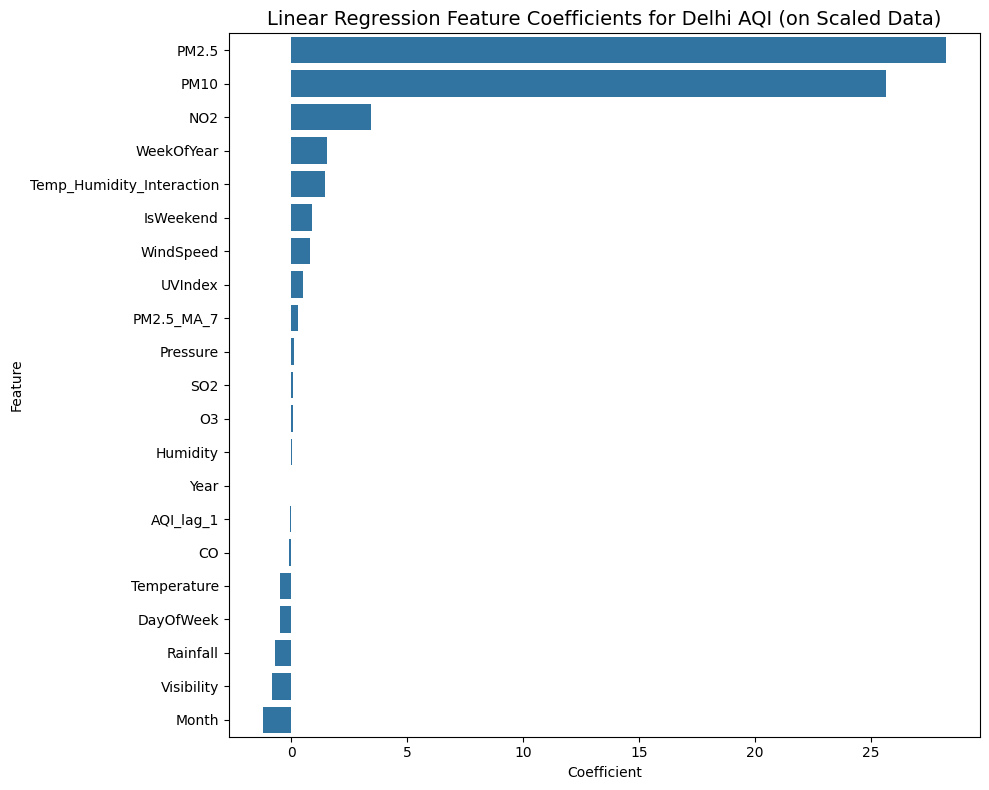

In [7]:
# 3. Model Analysis : Feature Coefficients (Linear Regression)
print("\n--- Linear Regression: Scaled Feature Coefficients ---")

# Create a DataFrame for scaled coefficients
coefficients = pd.DataFrame({
    "Feature": features, 
    "Coefficient": lr_model.coef_
}).sort_values(by = "Coefficient", ascending = False)

# Plotting the Coefficients
plt.figure(figsize=(10, 8))
sns.barplot(data = coefficients, x = "Coefficient", y = "Feature")
plt.title(f"Linear Regression Feature Coefficients for {city_name} AQI (on Scaled Data)", fontsize = 14)
plt.tight_layout()
plt.savefig("Image/lr_coefficients.png")


--- Random Forest: Feature Importance


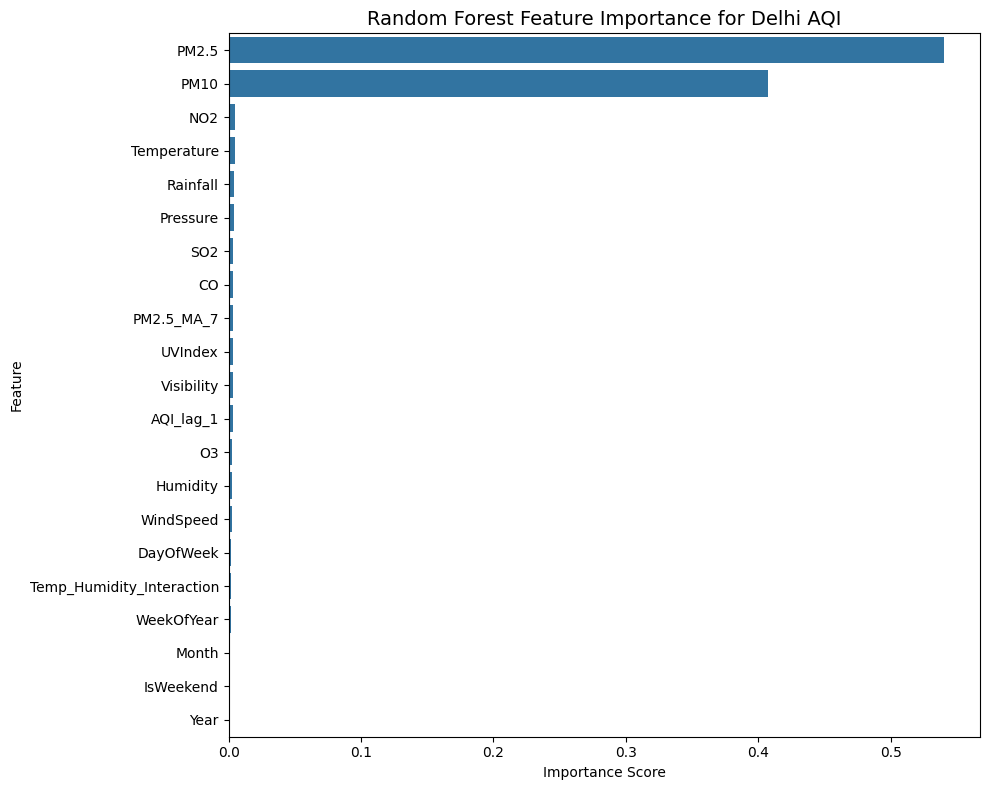

In [8]:
# 4. Model Analysis: Feature Importance (Random Forest)
print("\n--- Random Forest: Feature Importance")

# Get Feature importance
feature_importance_rf = pd.Series(rf_model.feature_importances_, index = features).sort_values(ascending = False)

# Plotting the importances
plt.figure(figsize = (10, 8))
sns.barplot(x = feature_importance_rf.values, y = feature_importance_rf.index)
plt.title(f"Random Forest Feature Importance for {city_name} AQI", fontsize = 14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("Image/rf_feature_importance.png")



--- Linear Regression: Residual Analysis---


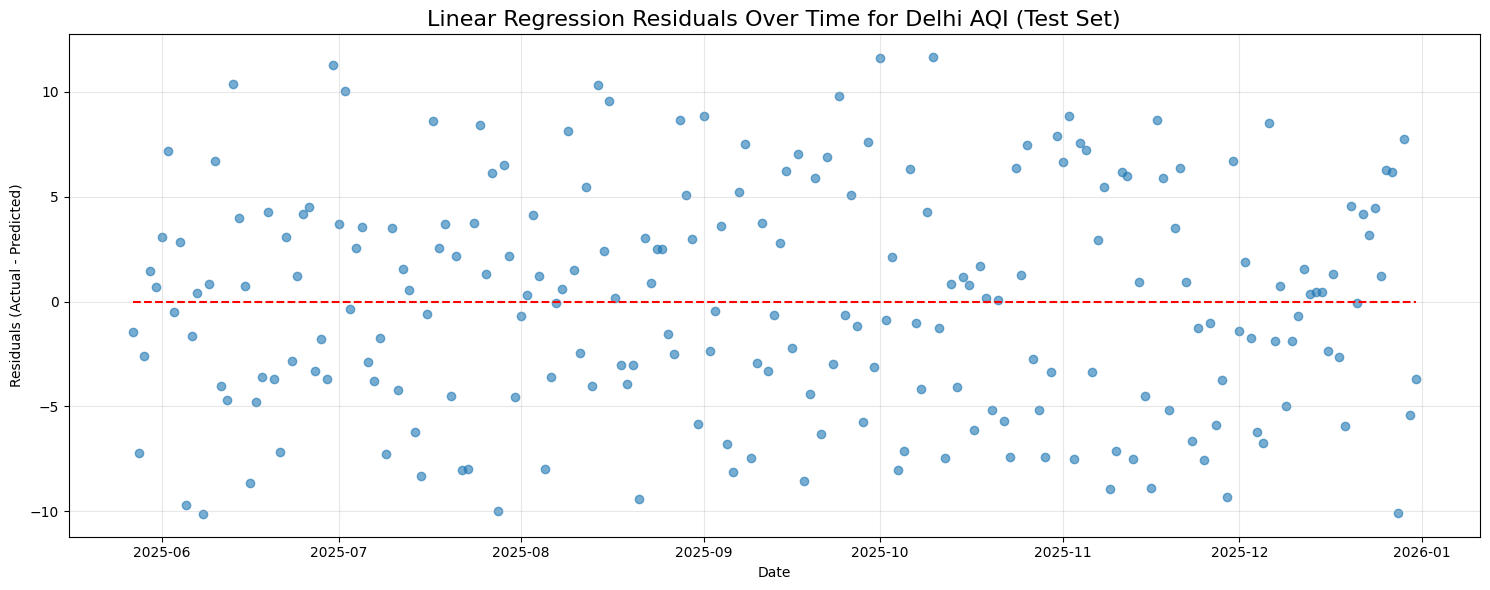

In [9]:
# 5. Model Ana;ysis: Residual Plot (Linear Regression)
print("\n--- Linear Regression: Residual Analysis---")

# Calculate residuals 
residuals = y_test - y_pred_lr
test_dates = y_test.index

# Plotting Residuals vs Time
plt.figure(figsize =(15, 6))
plt.scatter(test_dates, residuals, alpha = 0.6)
plt.hlines(0, test_dates.min(), test_dates.max(), colors = "red", linestyles = "--")
plt.title(f"Linear Regression Residuals Over Time for {city_name} AQI (Test Set)", fontsize = 16)
plt.xlabel("Date")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.savefig("Image/lr_residuals_time.png")
